# <img src="https://github.com/JuliaLang/julia-logo-graphics/raw/master/images/julia-logo-color.png" height="100" /> _Colab Notebook Template_

## Instructions
1. Work on a copy of this notebook: _File_ > _Save a copy in Drive_ (you will need a Google account). Alternatively, you can download the notebook using _File_ > _Download .ipynb_, then upload it to [Colab](https://colab.research.google.com/).
2. If you need a GPU: _Runtime_ > _Change runtime type_ > _Harware accelerator_ = _GPU_.
3. Execute the following cell (click on it and press Ctrl+Enter) to install Julia, IJulia and other packages (if needed, update `JULIA_VERSION` and the other parameters). This takes a couple of minutes.
4. Reload this page (press Ctrl+R, or ⌘+R, or the F5 key) and continue to the next section.

_Notes_:
* If your Colab Runtime gets reset (e.g., due to inactivity), repeat steps 2, 3 and 4.
* After installation, if you want to change the Julia version or activate/deactivate the GPU, you will need to reset the Runtime: _Runtime_ > _Factory reset runtime_ and repeat steps 3 and 4.

In [1]:
%%shell
set -e

#---------------------------------------------------#
JULIA_VERSION="1.8.2" # any version ≥ 0.7.0
JULIA_PACKAGES="IJulia BenchmarkTools"
JULIA_PACKAGES_IF_GPU="CUDA" # or CuArrays for older Julia versions
JULIA_NUM_THREADS=2
#---------------------------------------------------#

if [ -z `which julia` ]; then
  # Install Julia
  JULIA_VER=`cut -d '.' -f -2 <<< "$JULIA_VERSION"`
  echo "Installing Julia $JULIA_VERSION on the current Colab Runtime..."
  BASE_URL="https://julialang-s3.julialang.org/bin/linux/x64"
  URL="$BASE_URL/$JULIA_VER/julia-$JULIA_VERSION-linux-x86_64.tar.gz"
  wget -nv $URL -O /tmp/julia.tar.gz # -nv means "not verbose"
  tar -x -f /tmp/julia.tar.gz -C /usr/local --strip-components 1
  rm /tmp/julia.tar.gz

  # Install Packages
  nvidia-smi -L &> /dev/null && export GPU=1 || export GPU=0
  if [ $GPU -eq 1 ]; then
    JULIA_PACKAGES="$JULIA_PACKAGES $JULIA_PACKAGES_IF_GPU"
  fi
  for PKG in `echo $JULIA_PACKAGES`; do
    echo "Installing Julia package $PKG..."
    julia -e 'using Pkg; pkg"add '$PKG'; precompile;"' &> /dev/null
  done

  # Install kernel and rename it to "julia"
  echo "Installing IJulia kernel..."
  julia -e 'using IJulia; IJulia.installkernel("julia", env=Dict(
      "JULIA_NUM_THREADS"=>"'"$JULIA_NUM_THREADS"'"))'
  KERNEL_DIR=`julia -e "using IJulia; print(IJulia.kerneldir())"`
  KERNEL_NAME=`ls -d "$KERNEL_DIR"/julia*`
  mv -f $KERNEL_NAME "$KERNEL_DIR"/julia

  echo ''
  echo "Successfully installed `julia -v`!"
  echo "Please reload this page (press Ctrl+R, ⌘+R, or the F5 key) then"
  echo "jump to the 'Checking the Installation' section."
fi

Unrecognized magic `%%shell`.

Julia does not use the IPython `%magic` syntax.   To interact with the IJulia kernel, use `IJulia.somefunction(...)`, for example.  Julia macros, string macros, and functions can be used to accomplish most of the other functionalities of IPython magics.


# Checking the Installation
The `versioninfo()` function should print your Julia version and some other info about the system:

In [2]:
versioninfo()

Julia Version 1.8.2
Commit 36034abf260 (2022-09-29 15:21 UTC)
Platform Info:
  OS: Linux (x86_64-linux-gnu)
  CPU: 2 × Intel(R) Xeon(R) CPU @ 2.20GHz
  WORD_SIZE: 64
  LIBM: libopenlibm
  LLVM: libLLVM-13.0.1 (ORCJIT, broadwell)
  Threads: 2 on 2 virtual cores
Environment:
  LD_LIBRARY_PATH = /usr/local/nvidia/lib:/usr/local/nvidia/lib64
  JULIA_NUM_THREADS = 2


In [3]:
using Pkg
Pkg.add("CSV")
Pkg.add("DataFrames")
Pkg.add("Git")
Pkg.add("Lathe")
Pkg.add("Plots")
Pkg.add("Images")
Pkg.add("Colors")
Pkg.add("Flux")
Pkg.add("MLDataUtils")

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.8/Project.toml`
  No Changes to `~/.julia/environments/v1.8/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.8/Project.toml`
  No Changes to `~/.julia/environments/v1.8/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.8/Project.toml`
  No Changes to `~/.julia/environments/v1.8/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.8/Project.toml`
  No Changes to `~/.julia/environments/v1.8/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.8/Project.toml`
  No Changes to `~/.julia/environments/v1.8/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.8/Project.toml`
  No Changes to `~/.julia/environments/v1.8/Manifest.toml`
   Resolving package versions...
  No Ch

In [4]:
using Git

# Replace "repository_url" with the actual URL of your Git repository
repository_url = ""
clone_dir = "/content/"  # Change this to the desired local directory name

run(`git clone https://github.com/Parthiee/Gesture-Recognition-for-Sign-Language`)

fatal: destination path 'Gesture-Recognition-for-Sign-Language' already exists and is not an empty directory.


LoadError: failed process: Process(`[4mgit[24m [4mclone[24m [4mhttps://github.com/Parthiee/Gesture-Recognition-for-Sign-Language[24m`, ProcessExited(128)) [128]


In [5]:
using CSV
using DataFrames

df_train = CSV.read("/content/Gesture-Recognition-for-Sign-Language/data/sign_mnist_train.csv", DataFrame)
df_test = CSV.read("/content/Gesture-Recognition-for-Sign-Language/data/sign_mnist_test.csv", DataFrame)


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,pixel11,pixel12
,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64
1,6,149,149,150,150,150,151,151,150,151,152,152,152
2,5,126,128,131,132,133,134,135,135,136,138,137,137
3,10,85,88,92,96,105,123,135,143,147,152,157,163
4,0,203,205,207,206,207,209,210,209,210,209,208,207
5,3,188,191,193,195,199,201,202,203,203,203,204,204
6,21,72,79,87,101,115,124,131,135,139,142,144,147
7,10,93,100,112,118,123,127,131,133,136,139,140,143
8,14,177,177,177,177,177,178,179,179,178,179,179,178
9,3,191,194,196,198,201,203,204,205,205,205,205,206


In [6]:
uniqueEntries = sort(unique(df_train[:,"label"]))
println(uniqueEntries)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]


In [7]:
#using Lathe.preprocess: TrainTestSplit
#train, test = TrainTestSplit(df,0.8)

trainY = df_train[!,"label"]
trainX = select!(df_train, Not([:label]))

testY = df_test[!,"label"]
testX = select!(df_test, Not([:label]))

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,pixel11,pixel12,pixel13
,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64
1,149,149,150,150,150,151,151,150,151,152,152,152,152
2,126,128,131,132,133,134,135,135,136,138,137,137,138
3,85,88,92,96,105,123,135,143,147,152,157,163,168
4,203,205,207,206,207,209,210,209,210,209,208,207,207
5,188,191,193,195,199,201,202,203,203,203,204,204,204
6,72,79,87,101,115,124,131,135,139,142,144,147,150
7,93,100,112,118,123,127,131,133,136,139,140,143,144
8,177,177,177,177,177,178,179,179,178,179,179,178,179
9,191,194,196,198,201,203,204,205,205,205,205,206,206


In [8]:
trainX = trainX./256
testX = testX./256

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,0.582031,0.582031,0.585938,0.585938,0.585938,0.589844,0.589844,0.585938,0.589844,0.59375
2,0.492188,0.5,0.511719,0.515625,0.519531,0.523438,0.527344,0.527344,0.53125,0.539062
3,0.332031,0.34375,0.359375,0.375,0.410156,0.480469,0.527344,0.558594,0.574219,0.59375
4,0.792969,0.800781,0.808594,0.804688,0.808594,0.816406,0.820312,0.816406,0.820312,0.816406
5,0.734375,0.746094,0.753906,0.761719,0.777344,0.785156,0.789062,0.792969,0.792969,0.792969
6,0.28125,0.308594,0.339844,0.394531,0.449219,0.484375,0.511719,0.527344,0.542969,0.554688
7,0.363281,0.390625,0.4375,0.460938,0.480469,0.496094,0.511719,0.519531,0.53125,0.542969
8,0.691406,0.691406,0.691406,0.691406,0.691406,0.695312,0.699219,0.699219,0.695312,0.699219
9,0.746094,0.757812,0.765625,0.773438,0.785156,0.792969,0.796875,0.800781,0.800781,0.800781


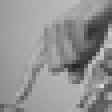

In [9]:
using Images
function plot_image(pixel_values)
    img_matrix = reshape(pixel_values, (28, 28))  # Reshape pixel values into a 3x3 matrix
    img = Gray.(img_matrix)  # Convert to Gray image type
    return img # Display the image using heatmap
end

arr = Array(trainX[2,:])

#println(arr)
plot_image(arr)

In [10]:
#Convert dataframes to Array

trainY = Float32.(Array(trainY))
trainX = Float32.(Array(trainX))

testY = Float32.(Array(testY))
testX = Float32.(Array(testX))


7172×784 Matrix{Float32}:
 0.582031  0.582031  0.585938  0.585938  0.585938  …  0.414062  0.4375     0.46875    0.417969
 0.492188  0.5       0.511719  0.515625  0.519531     0.71875   0.71875    0.710938   0.703125
 0.332031  0.34375   0.359375  0.375     0.410156     0.882812  0.878906   0.875      0.867188
 0.792969  0.800781  0.808594  0.804688  0.808594     0.898438  0.9375     0.988281   0.996094
 0.734375  0.746094  0.753906  0.761719  0.777344     0.191406  0.179688   0.179688   0.207031
 0.28125   0.308594  0.339844  0.394531  0.449219  …  0.757812  0.761719   0.761719   0.757812
 0.363281  0.390625  0.4375    0.460938  0.480469     0.707031  0.707031   0.707031   0.714844
 0.691406  0.691406  0.691406  0.691406  0.691406     0.863281  0.863281   0.859375   0.855469
 0.746094  0.757812  0.765625  0.773438  0.785156     0.253906  0.242188   0.242188   0.265625
 0.667969  0.671875  0.671875  0.675781  0.675781     0.714844  0.332031   0.253906   0.484375
 0.828125  0.828125  0.8

In [11]:
trainX[1,:]

784-element Vector{Float32}:
 0.41796875
 0.4609375
 0.49609375
 0.5234375
 0.54296875
 0.55859375
 0.5703125
 0.5859375
 0.59765625
 0.609375
 0.6171875
 0.625
 0.63671875
 ⋮
 0.80859375
 0.80859375
 0.80859375
 0.80859375
 0.80859375
 0.80859375
 0.8046875
 0.8046875
 0.8046875
 0.796875
 0.79296875
 0.7890625

In [25]:
using Flux

model = Chain(
    Dense(784 => 630, sigmoid),
    Dense(630 => 25, sigmoid),
    softmax
)


Chain(
  Dense(784 => 630, σ),                 # 494_550 parameters
  Dense(630 => 25, σ),                  # 15_775 parameters
  NNlib.softmax,
)                   # Total: 4 arrays, 510_325 parameters, 1.947 MiB.

In [26]:
function toDataLoader(X,Y)
  data = []
    for i in 1:size(trainX, 1)
      push!(data, (trainX[i, :], trainY[i]))
    end
    data = Flux.DataLoader(data, shuffle=true)

    return data
end

dataTrain = toDataLoader(trainX, trainY)


27455-element DataLoader(::Vector{Any}, shuffle=true)
  with first element:
  1-element Vector{Any}

In [27]:

optimizer = opt = Flux.setup(Descent(), model)

function loss(model, x, y)
    loss_ = Flux.crossentropy(model(x), Flux.onehotbatch(y, 0:24))
    return loss_
end


function accuracy()
    correct = 0
    for index in 1:length(y_test)
        probs = model(testX[index,:])
        predicted_digit = argmax(probs)[1]-1
        if predicted_digit == y_test[index]
            correct +=1
        end
    end
    return correct/length(y_test)
end

accuracy (generic function with 1 method)

In [29]:

y_test = testY
x_test = testX

for epoch in 1:50

    Flux.train!(loss, model, dataTrain.data, optimizer)
    acc = accuracy()
    println(" Accuracy : $acc")

end


 Accuracy : 0.7282487451199108
 Accuracy : 0.732989403234802
 Accuracy : 0.7438650306748467
 Accuracy : 0.7412158393753486
 Accuracy : 0.7513943112102621
 Accuracy : 0.7527886224205242
 Accuracy : 0.7587841606246514
 Accuracy : 0.7589235917456776
 Accuracy : 0.7625488008923592
 Accuracy : 0.7640825432236475
 Accuracy : 0.7654768544339097
 Accuracy : 0.7668711656441718
 Accuracy : 0.77356385945343
 Accuracy : 0.775515895147797
 Accuracy : 0.7791411042944786
 Accuracy : 0.7780256553262688
 Accuracy : 0.7771890686001115
 Accuracy : 0.77356385945343
 Accuracy : 0.771611823759063
 Accuracy : 0.77356385945343
 Accuracy : 0.7734244283324038
 Accuracy : 0.7707752370329057
 Accuracy : 0.7703569436698271
 Accuracy : 0.7717512548800892
 Accuracy : 0.7707752370329057
 Accuracy : 0.7706358059118795
 Accuracy : 0.7697992191857222
 Accuracy : 0.7682654768544339
 Accuracy : 0.7678471834913553
 Accuracy : 0.7691020635805912
 Accuracy : 0.7707752370329057
 Accuracy : 0.7707752370329057
 Accuracy : 0.771